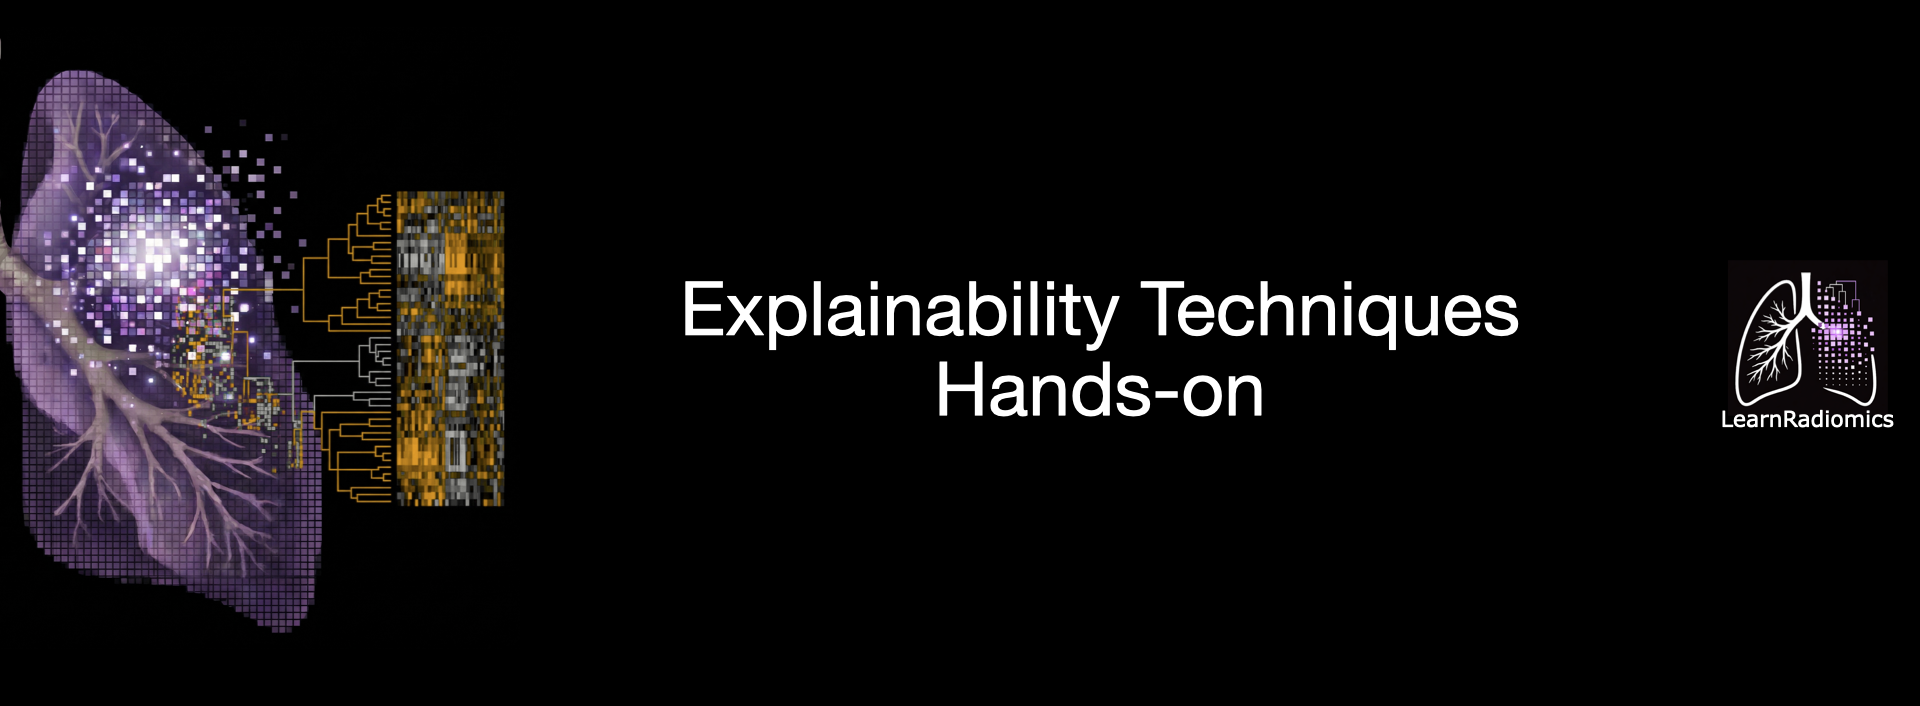

In [ ]:
!pip -q install torchxrayvision captum grad-cam shap

!git clone https://github.com/mlmed/gifsplanation

In [ ]:
import sys,os
sys.path.insert(0,"./gifsplanation/")
sys.path.insert(0,"../torchxrayvision/")
import skimage
from skimage import io
from skimage.transform import resize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import torch, torchvision
import torchxrayvision as xrv
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn.functional as F

import attribution
import shap
import requests
import json
import warnings
warnings.filterwarnings('ignore')

## Descarga de token de kaggle que permite acceder al set de datos
json_response= requests.get("https://raw.github.com/learnradiomics/Image_processing/main/kaggle.json")
token = json.loads(json_response.text)
with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Carga de datos desde Kaggle
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/cxr-images-sample
! unzip /content/cxr-images-sample.zip

### Verified GPU
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
print(device)

In [ ]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
device

## Functions for visualization and explainability

In [ ]:
def predict_torchxrayvision(img, model):
    import torch

    device = next(model.parameters()).device

    img = img.float().to(device)
    model.eval()

    with torch.no_grad():
        outputs = model(img)

    return outputs.detach().cpu()

def move_gifsplanation_inputs_to_device(image, model, ae, use_cuda=True):
    import torch
    import numpy as np

    device = torch.device("cuda" if use_cuda and torch.cuda.is_available() else "cpu")

    if isinstance(image, np.ndarray):
        image = torch.from_numpy(image).float()

    image = image.float().to(device)
    model = model.to(device)
    ae = ae.to(device)

    model.eval()
    ae.eval()

    print("Using device:", device)
    print("Image:", image.shape, image.device, image.dtype)
    print("Model:", next(model.parameters()).device, next(model.parameters()).dtype)
    print("AE:", next(ae.parameters()).device, next(ae.parameters()).dtype)

    return image, model, ae, device

def prepare_single_cxr_for_xrv(cxr_data, idx, device):
    """
    Toma cxr_data con forma [N, H, W] uint8
    y devuelve una imagen compatible con TorchXRayVision:
    [1, 1, 224, 224]
    """

    img_np = cxr_data[idx].astype(np.float32)

    # Normalización esperada por TorchXRayVision
    img_np = xrv.datasets.normalize(img_np, 255)

    # [H, W] -> [1, 1, H, W]
    img_tensor = torch.from_numpy(img_np).float()
    img_tensor = img_tensor.unsqueeze(0).unsqueeze(0)

    img_tensor = img_tensor.to(device)

    return img_tensor



class GradCAM:
    def __init__(self, model, target_layer):
        """
        model: modelo PyTorch entrenado.
        target_layer: capa convolucional objetivo, por ejemplo model.layer4[-1].
        """
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = target_layer.register_forward_hook(
            self.save_activations
        )

        self.backward_hook = target_layer.register_full_backward_hook(
            self.save_gradients
        )

    def save_activations(self, module, input, output):
        self.activations = output.detach()

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove_hooks(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def __call__(self, input_tensor, target_class=None):
        """
        input_tensor: tensor (B, 3, H, W), ya normalizado como durante entrenamiento.
        target_class: clase objetivo. Si None, usa la clase predicha.
        """

        self.model.eval()
        self.model.zero_grad()

        logits = self.model(input_tensor)

        if target_class is None:
            target_class = logits.argmax(dim=1).item()

        score = logits[:, target_class].sum()
        score.backward()

        # gradients:   (B, C, h, w)
        # activations: (B, C, h, w)
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=input_tensor.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        # Normalizar CAM a [0, 1]
        cam_min = cam.min(dim=2, keepdim=True)[0].min(dim=3, keepdim=True)[0]
        cam_max = cam.max(dim=2, keepdim=True)[0].max(dim=3, keepdim=True)[0]

        cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

        return cam.detach(), logits.detach()

In [ ]:
def show_gradcam(img_1ch, cam, alpha=0.4):
    """
    img_1ch: tensor (1, H, W), rango [0, 1]
    cam: tensor (1, 1, H, W), rango [0, 1]
    """

    img = img_1ch.squeeze().cpu().numpy()
    heatmap = cam.squeeze().cpu().numpy()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Imagen original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(img, cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


def gray_to_rgb(x):
    """
    Convierte imágenes (N,H,W,1) a (N,H,W,3)
    para visualización con SHAP.
    """
    if x.shape[-1] == 1:
        return np.repeat(x, 3, axis=-1)
    elif x.shape[-1] == 3:
        return x
    else:
        raise ValueError(f"Esperaba C=1 o C=3. Recibido C={x.shape[-1]}")


#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#model = model.to(device)
#model.eval()


def predict_fn_shap_torchvision_gray_model(x_rgb):
    """
    SHAP recibe:
        x_rgb: (N,H,W,3)

    Modelo recibe:
        x_gray: (N,1,H,W)

    Devuelve:
        probs: (N,18)
    """

    # Tomar solo un canal desde la imagen RGB artificial
    x_gray = x_rgb[..., 0:1].astype("float32")

    # Si viene 0-255, pasar a 0-1
    if x_gray.max() > 1.0:
        x_gray = x_gray / 255.0

    # (N,H,W,1) -> (N,1,H,W)
    x_tensor = torch.from_numpy(x_gray).permute(0, 3, 1, 2).to(device)

    # Ajusta según la normalización usada en entrenamiento
    mean = torch.tensor([0.5], device=device).view(1, 1, 1, 1)
    std = torch.tensor([0.5], device=device).view(1, 1, 1, 1)

    x_tensor = (x_tensor - mean) / std

    with torch.no_grad():
        logits = model(x_tensor)      # (N,18)
        probs = F.softmax(logits, dim=1)

    return probs.detach().cpu().numpy()

In [ ]:
def plot_single_shap_image(
    shap_values,
    image_batch,
    sample_idx=0,
    output_idx=0,
    channel_aggregation="mean",
    alpha=0.45,
    percentile=99,
    figsize=(6, 6)
):

    # -------------------------
    # 1. Extraer imagen
    # -------------------------
    img = image_batch[sample_idx].copy()

    # Convertir imagen a rango visual 0-1
    img = img.astype("float32")

    if img.max() > 1.0:
        img_display = img / 255.0
    else:
        img_display = img.copy()

    img_display = np.clip(img_display, 0, 1)

    # -------------------------
    # 2. Extraer SHAP values
    # -------------------------
    sv = shap_values.values

    print("Shape original shap values:", sv.shape)
    print("Shape imagen:", image_batch.shape)

    # Caso frecuente:
    # (N,H,W,C,1) si usaste outputs=[target_idx]
    if sv.ndim == 5:
        sv = sv[sample_idx, ..., output_idx]  # (H,W,C)

    # Caso:
    # (N,H,W,C)
    elif sv.ndim == 4:
        sv = sv[sample_idx]  # (H,W,C)

    # Caso:
    # (H,W,C)
    elif sv.ndim == 3:
        pass

    else:
        raise ValueError(f"Shape de SHAP values no esperado: {sv.shape}")

    print("Shape SHAP para visualización:", sv.shape)

    # -------------------------
    # 3. Agregar canales
    # -------------------------
    if sv.ndim == 3:
        if channel_aggregation == "mean":
            sv_2d = sv.mean(axis=-1)
        elif channel_aggregation == "sum":
            sv_2d = sv.sum(axis=-1)
        elif channel_aggregation is None:
            sv_2d = sv[..., 0]
        else:
            raise ValueError("channel_aggregation debe ser 'mean', 'sum' o None")
    else:
        sv_2d = sv

    # -------------------------
    # 4. Escalar SHAP para visualización
    # -------------------------
    vmax = np.percentile(np.abs(sv_2d), percentile)

    if vmax == 0:
        vmax = np.max(np.abs(sv_2d)) + 1e-8

    # -------------------------
    # 5. Graficar un solo objeto
    # -------------------------
    plt.figure(figsize=figsize)

    plt.imshow(img_display, cmap="gray")
    plt.imshow(
        sv_2d,
        cmap="bwr",
        alpha=alpha,
        vmin=-vmax,
        vmax=vmax
    )

    plt.axis("off")
    plt.colorbar(fraction=0.046, pad=0.04, label="SHAP value")
    plt.title("SHAP explanation - single image")
    plt.show()

### Data Upload

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cxr_data = np.load('/content/CXR_samples_from_RSNA_Challenge.npy')

print(cxr_data.shape, cxr_data.dtype, cxr_data.min(), cxr_data.max())

In [ ]:
## Data Visualization

fig, axes1 = plt.subplots(2,3,figsize=(10,10))
for j in range(2):
    for k in range(3):
        i = np.random.randint(0, cxr_data.shape[0])
        axes1[j][k].set_axis_off()
        axes1[j][k].imshow(cxr_data[i,:,:], cmap='gray')
        axes1[j][k].set_title("case id: {}".format(i))

plt.show()

In [ ]:
## Pre-trained Model an AutoEncoder

ae = xrv.autoencoders.ResNetAE(weights="101-elastic").to(device)
model = xrv.models.DenseNet(weights="all").to(device)
#model.pathologies

In [ ]:
### Upload of external image

#img_path = '/content/caso_rx.jpg'

#external_img = io.imread(img_path)
#external_img_gray = external_img[:,:,0].astype(np.float32)
#external_img_gray_res = resize(external_img_gray ,(224,224), anti_aliasing=True)

#external_img_gray_res = xrv.datasets.normalize(external_img_gray_res, 255)

#img = torch.from_numpy(external_img_gray_res).float()
#img = img.unsqueeze(0).unsqueeze(0)
#img = img.to(device)
#img.shape

### Model Inference

In [ ]:
idx = 5
img = prepare_single_cxr_for_xrv(cxr_data, idx, device)

print(img.shape)
print(img.dtype)
print(img.device)
print(img.min(), img.max())

plt.figure(figsize=(6,6))
plt.imshow(cxr_data[idx,:,:], cmap='gray')
#plt.imshow(img.squeeze().cpu().numpy(), cmap='gray')
plt.title("Imagen a evaluar idx:{}".format(idx))
plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
img = img.float().to(device)

## Inferencia sobre imagen:
outputs = predict_torchxrayvision(img, model)

scores = outputs[0].numpy()

df_results = (
    pd.DataFrame({
        "Pathology": model.pathologies,
        "Score": scores
    })
    .sort_values("Score", ascending=False)
)

df_results

### Explainability techniques: GradCam

In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)
model.eval()

target_layer = model.features.denseblock3.denselayer24.conv1

grad_cam = GradCAM(
    model=model,
    target_layer=target_layer)

cam, logits = grad_cam(
    input_tensor=img,
    target_class=1)

show_gradcam(
    img_1ch=img,
    cam=cam,
    alpha=0.4)

### Explainability Techniques: SHAP

In [ ]:
class_names = model.pathologies

X_explain_gray = cxr_data[idx].astype("float32")
X_explain_gray = np.expand_dims(X_explain_gray, axis=-1)

X_explain_rgb = gray_to_rgb(X_explain_gray)
X_explain_rgb_batch = np.expand_dims(X_explain_rgb, axis=0)

masker = shap.maskers.Image(
    "blur(64,64)",
    X_explain_rgb_batch.shape[1:]   # (224,224,3)
)

explainer = shap.Explainer(
    predict_fn_shap_torchvision_gray_model,
    masker,
    output_names=class_names
)

shap_values_target = explainer(
    X_explain_rgb_batch,
    max_evals=1000,
    batch_size=16,
    outputs= [int(np.argmax(outputs))]
)



In [ ]:
plot_single_shap_image(
    shap_values_target,
    X_explain_rgb_batch,
    sample_idx=0,
    output_idx=0,
    channel_aggregation="mean",
    alpha=0.45
)

Explainability Techniques: CounterFactual Explanations

In [ ]:
target = "Mass"

image, model, ae, device = move_gifsplanation_inputs_to_device(img, model, ae)

%matplotlib inline
attribution.generate_video(
    img,
    model,
    target,
    ae,
    target_filename="test",
    border=False,
    show=True,
    ffmpeg_path="ffmpeg"
)